In [ ]:
# pip install PIL matplotlib

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix


In [ ]:
import pathlib

train_path = pathlib.Path('dataset/train')
valid_path = pathlib.Path('dataset/valid')
test_path = pathlib.Path('dataset/test')

In [ ]:
print(train_path)
print(list(train_path.glob('*/*.jpg')))

dataset/train
[PosixPath('dataset/train/lacrosse/016.jpg'), PosixPath('dataset/train/lacrosse/002.jpg'), PosixPath('dataset/train/lacrosse/003.jpg'), PosixPath('dataset/train/lacrosse/017.jpg'), PosixPath('dataset/train/lacrosse/149.jpg'), PosixPath('dataset/train/lacrosse/029.jpg'), PosixPath('dataset/train/lacrosse/001.jpg'), PosixPath('dataset/train/lacrosse/015.jpg'), PosixPath('dataset/train/lacrosse/014.jpg'), PosixPath('dataset/train/lacrosse/028.jpg'), PosixPath('dataset/train/lacrosse/148.jpg'), PosixPath('dataset/train/lacrosse/004.jpg'), PosixPath('dataset/train/lacrosse/010.jpg'), PosixPath('dataset/train/lacrosse/038.jpg'), PosixPath('dataset/train/lacrosse/039.jpg'), PosixPath('dataset/train/lacrosse/011.jpg'), PosixPath('dataset/train/lacrosse/005.jpg'), PosixPath('dataset/train/lacrosse/013.jpg'), PosixPath('dataset/train/lacrosse/007.jpg'), PosixPath('dataset/train/lacrosse/006.jpg'), PosixPath('dataset/train/lacrosse/012.jpg'), PosixPath('dataset/train/lacrosse/129.jp

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

In [ ]:
# create training dataset
image_count = len(list(train_path.glob('*/*.jpg')))
print(f"{train_path} has {image_count} photos. ")

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_path,
  validation_split=None,
  subset=None,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


dataset/train has 13572 photos. 
Found 13572 files belonging to 100 classes.


In [ ]:
# create vaild dataset

image_count = len(list(valid_path.glob('*/*.jpg')))
print(f"{valid_path} has {image_count} photos. ")
valid_ds = tf.keras.utils.image_dataset_from_directory(
  valid_path,
  validation_split=None,
  subset=None,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)


dataset/valid has 500 photos. 
Found 500 files belonging to 100 classes.


In [ ]:
# create testing dataset


image_count = len(list(test_path.glob('*/*.jpg')))
print(f"{test_path} has {image_count} photos. ")
test_ds = tf.keras.utils.image_dataset_from_directory(
  test_path,
  validation_split=None,
  subset=None,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

dataset/test has 500 photos. 
Found 500 files belonging to 100 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['air hockey', 'ampute football', 'archery', 'arm wrestling', 'axe throwing', 'balance beam', 'barell racing', 'baseball', 'basketball', 'baton twirling', 'bike polo', 'billiards', 'bmx', 'bobsled', 'bowling', 'boxing', 'bull riding', 'bungee jumping', 'canoe slamon', 'cheerleading', 'chuckwagon racing', 'cricket', 'croquet', 'curling', 'disc golf', 'fencing', 'field hockey', 'figure skating men', 'figure skating pairs', 'figure skating women', 'fly fishing', 'football', 'formula 1 racing', 'frisbee', 'gaga', 'giant slalom', 'golf', 'hammer throw', 'hang gliding', 'harness racing', 'high jump', 'hockey', 'horse jumping', 'horse racing', 'horseshoe pitching', 'hurdles', 'hydroplane racing', 'ice climbing', 'ice yachting', 'jai alai', 'javelin', 'jousting', 'judo', 'lacrosse', 'log rolling', 'luge', 'motorcycle racing', 'mushing', 'nascar racing', 'olympic wrestling', 'parallel bar', 'pole climbing', 'pole dancing', 'pole vault', 'polo', 'pommel horse', 'rings', 'rock climbing', 'roller 

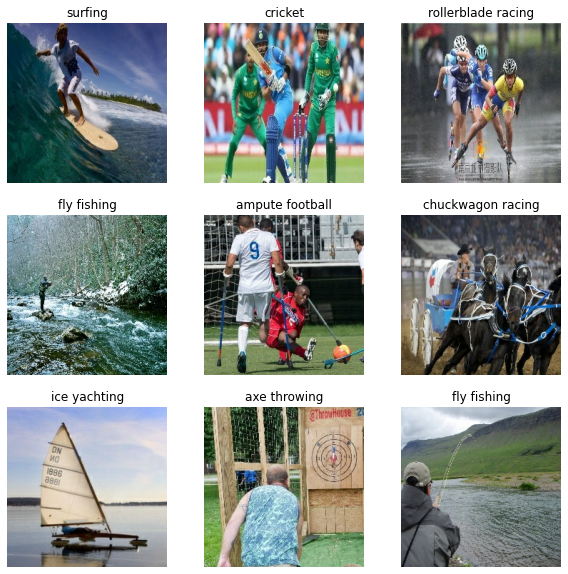

In [ ]:
# preview train_ds dataset
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

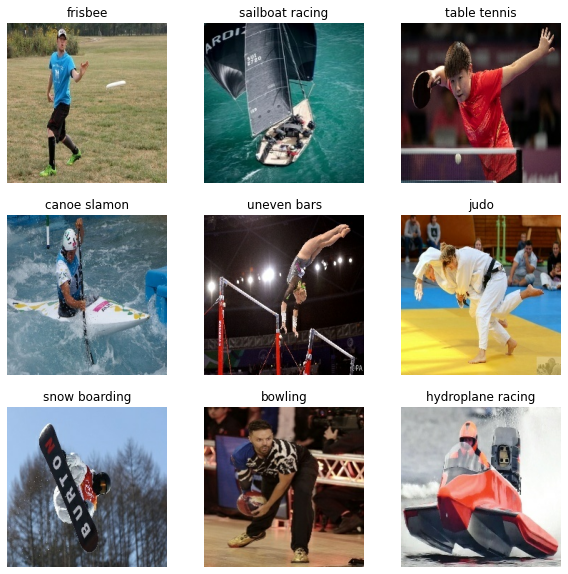

In [ ]:
# preview valid_ds dataset

plt.figure(figsize=(10, 10))

for images, labels in valid_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

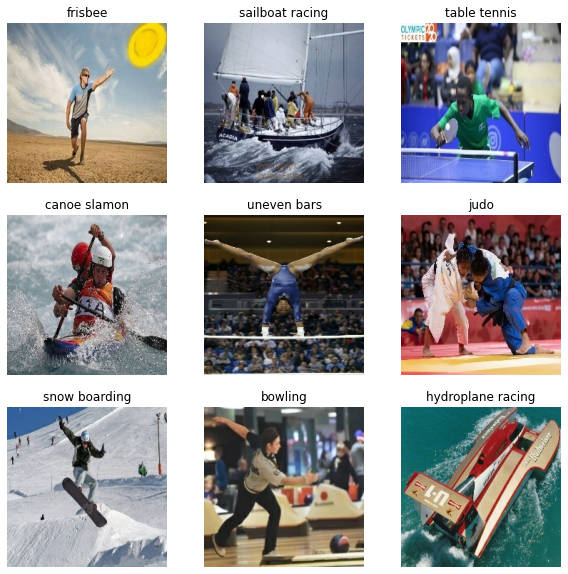

In [ ]:
# preview test_ds dataset

plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
# check the shape of train_ds
for image_batch, labels_batch in train_ds:
    print(image_batch.shape)
    print(labels_batch.shape)
    break

(32, 224, 224, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
# Using random data augmentation

data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)


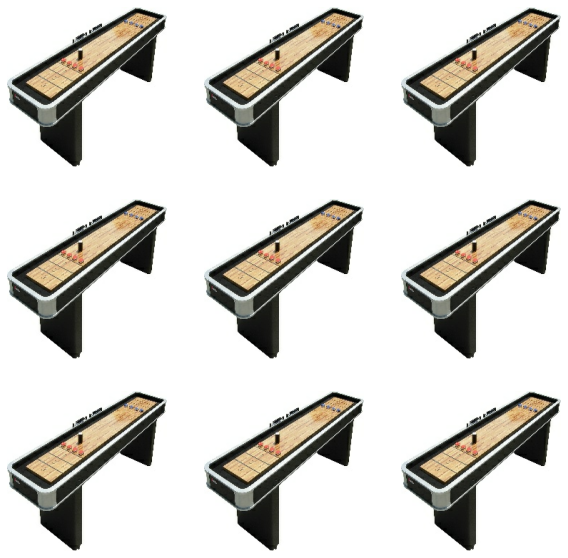

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")


In [ ]:
# Build a model

base_model = keras.applications.MobileNetV2(
    weights="imagenet",  # Load weights pre-trained on ImageNet.
    input_shape=(224, 224, 3),
    include_top=False,
)  # Do not include the ImageNet classifier at the top.

# Freeze the base_model
base_model.trainable = False

# Create new model on top
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Apply random data augmentation

# Pre-trained Xception weights requires that input be scaled
# from (0, 255) to a range of (-1., +1.), the rescaling layer
# outputs: `(inputs * scale) + offset`
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1)
x = scale_layer(x)

# The base model contains batchnorm layers. We want to keep them in inference mode
# when we unfreeze the base model for fine-tuning, so we make sure that the
# base_model is running in inference mode here.
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
# x =  keras.layers.Dense(256)(x)
# x = tf.keras.activations.relu(x)
# x = keras.layers.Dropout(0.1)(x)  # Regularize with dropout
# x =  keras.layers.Dense(256)(x)
# x = tf.keras.activations.relu(x)
# x = keras.layers.Dropout(0.1)(x)  # Regularize with dropout

num_classes = len(class_names)

outputs = keras.layers.Dense(num_classes)(x)
outputs = tf.keras.activations.softmax(outputs)

model = keras.Model(inputs, outputs)

model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 rescaling_2 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 100)               1281

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

epochs = 10
history = model.fit(train_ds, epochs=epochs, validation_data=valid_ds)

Epoch 1/10
425/425 [==============================] - 318s 742ms/step - loss: 1.7204 - accuracy: 0.5885 - val_loss: 0.6486 - val_accuracy: 0.8300
Epoch 2/10
425/425 [==============================] - 321s 755ms/step - loss: 0.7190 - accuracy: 0.8081 - val_loss: 0.4825 - val_accuracy: 0.8640
Epoch 3/10
425/425 [==============================] - 312s 734ms/step - loss: 0.5489 - accuracy: 0.8487 - val_loss: 0.4181 - val_accuracy: 0.8760
Epoch 4/10
425/425 [==============================] - 304s 715ms/step - loss: 0.4610 - accuracy: 0.8728 - val_loss: 0.3858 - val_accuracy: 0.8840
Epoch 5/10
425/425 [==============================] - 304s 714ms/step - loss: 0.3847 - accuracy: 0.8870 - val_loss: 0.3439 - val_accuracy: 0.8840
Epoch 6/10
425/425 [==============================] - 303s 712ms/step - loss: 0.3449 - accuracy: 0.9023 - val_loss: 0.3332 - val_accuracy: 0.9000
Epoch 7/10
425/425 [==============================] - 303s 713ms/step - loss: 0.3126 - accuracy: 0.9091 - val_loss: 0.3570 -

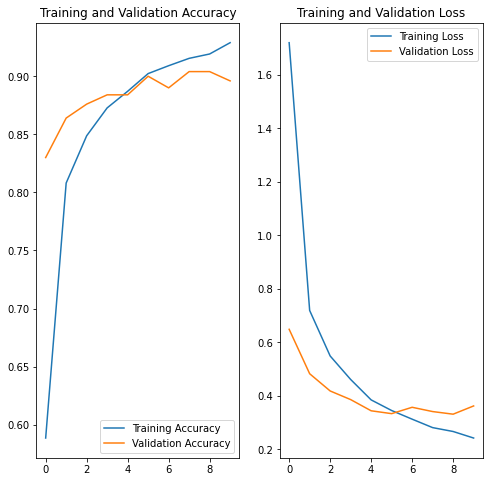

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('model_MV2-accuracy&loss.png')
plt.show()

In [ ]:
model.save("model_MV2.h5")